# Lab 13: Open-Ended Lab - CityLearn Solar Generation Forecasting (LSTM)

**Student Name:** Shaheer Khan  
**Registration Number:** 22JZELE0457  

---

## 1. Problem Statement

The objective is to develop a Long Short-Term Memory (LSTM) model to forecast **solar generation** using the CityLearn 2022 dataset. Accurate solar forecasting is critical for energy management and demand response in smart cities.

---


## 2. Import Libraries

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset

In [6]:
df = pd.read_csv(r'C:\Users\PMYLS\Documents\MachineLearningLaB\Building_2.csv')   
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8760, 7)


,date,kg_CO2/kWh,Outdoor Drybulb Temperature [C],Relative Humidity [%],Diffuse Solar Radiation [W/m2],Direct Solar Radiation [W/m2],Solar Generation [W/kW]
0,2022-08-01 00:00:00,0.170724,20.0,84,0,0,0.0
1,2022-08-01 01:00:00,0.157319,20.1,79,0,0,0.0
2,2022-08-01 02:00:00,0.154503,19.7,78,0,0,0.0
3,2022-08-01 03:00:00,0.150945,19.3,78,0,0,0.0
4,2022-08-01 04:00:00,0.151820,18.9,78,0,0,0.0


In [7]:
# Rename columns for easier use 
df.rename(columns={
    'date': 'timestamp',
    'Solar Generation [W/kW]': 'solar_generation'
}, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

## 3. Data Exploration & Cleaning

In [8]:
print("Missing Values:\n", df.isnull().sum())
df.fillna(method='ffill', inplace=True)

print("\nBasic Statistics:")
print(df['solar_generation'].describe())

Missing Values:
 kg_CO2/kWh                         0
Outdoor Drybulb Temperature [C]    0
Relative Humidity [%]              0
Diffuse Solar Radiation [W/m2]     0
Direct Solar Radiation [W/m2]      0
solar_generation                   0
dtype: int64

Basic Statistics:
count    8760.000000
mean      154.774259
std       226.196434
min         0.000000
25%         0.000000
50%         0.000000
75%       301.411458
max       786.083333
Name: solar_generation, dtype: float64


### Plot Solar Generation

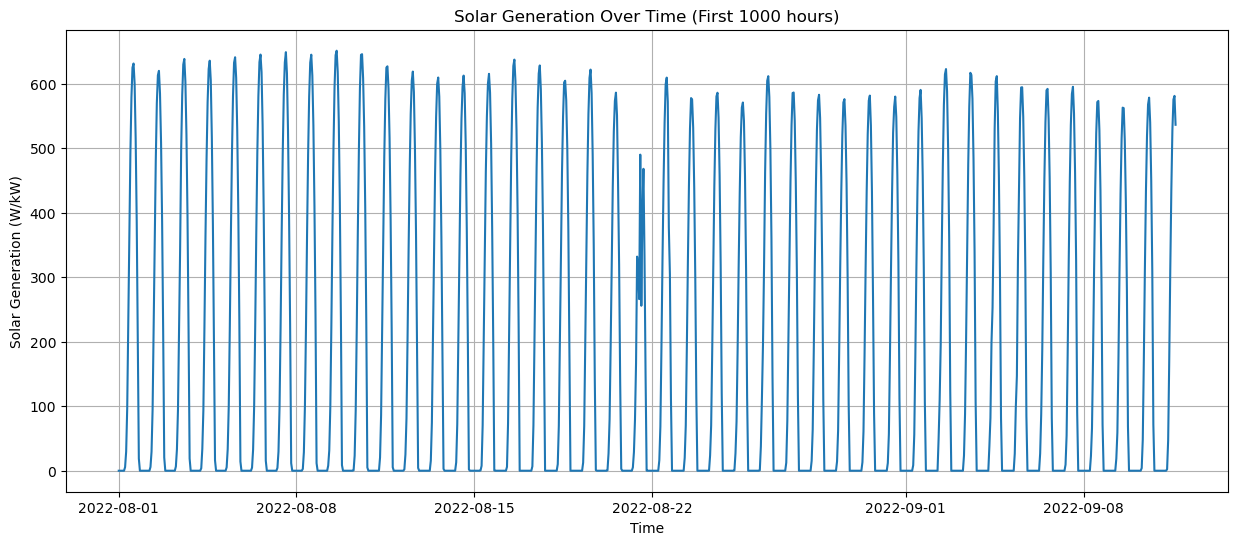

In [10]:
plt.figure(figsize=(15,6))
plt.plot(df['solar_generation'][:1000])
plt.title('Solar Generation Over Time (First 1000 hours)')
plt.xlabel('Time')
plt.ylabel('Solar Generation (W/kW)')
plt.grid(True)
plt.show()

## 4. Feature Engineering

In [11]:
# Temporal Features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Lag Features
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'solar_lag_{lag}'] = df['solar_generation'].shift(lag)

# Rolling Statistics
df['solar_roll_mean_24'] = df['solar_generation'].rolling(window=24).mean()
df['solar_roll_std_24'] = df['solar_generation'].rolling(window=24).std()

df.dropna(inplace=True)
print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (8736, 18)


## 5. Prepare Data for LSTM

In [12]:
feature_columns = [col for col in df.columns if col != 'solar_generation']
X = df[feature_columns].values
y = df['solar_generation'].values.reshape(-1, 1)

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Create sequences
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

print("Sequence Shape:", X_seq.shape)

Sequence Shape: (8712, 24, 17)


In [13]:
# Train-Validation-Test Split (70% - 20% - 10%)
total_samples = len(X_seq)

train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.20)
test_size = total_samples - train_size - val_size

X_train = X_seq[:train_size]
X_val   = X_seq[train_size:train_size + val_size]
X_test  = X_seq[train_size + val_size:]

y_train = y_seq[:train_size]
y_val   = y_seq[train_size:train_size + val_size]
y_test  = y_seq[train_size + val_size:]

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)
print(f"Total samples check: {train_size + val_size + test_size} = {total_samples}")

Train shape: (6098, 24, 17) (6098, 1)
Validation shape: (1742, 24, 17) (1742, 1)
Test shape: (872, 24, 17) (872, 1)
Total samples check: 8712 = 8712


## 6. Build & Train LSTM Model

In [19]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps, X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 24, 64)            20992     
                                                                 
 dropout_2 (Dropout)         (None, 24, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 33,441
Trainable params: 33,441
Non-trainable params: 0
_________________________________________________________________


In [20]:
# Callbacks
checkpoint = ModelCheckpoint('best_lstm_solar_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),   
    epochs=25,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/25
191/191 [==============================] - ETA: 0s - loss: 0.0238 - mae: 0.1075
Epoch 1: val_loss improved from inf to 0.02443, saving model to best_lstm_solar_model.h5
191/191 [==============================] - 16s 52ms/step - loss: 0.0238 - mae: 0.1075 - val_loss: 0.0244 - val_mae: 0.0975
Epoch 2/25
191/191 [==============================] - ETA: 0s - loss: 0.0126 - mae: 0.0718
Epoch 2: val_loss improved from 0.02443 to 0.01842, saving model to best_lstm_solar_model.h5
191/191 [==============================] - 9s 47ms/step - loss: 0.0126 - mae: 0.0718 - val_loss: 0.0184 - val_mae: 0.0838
Epoch 3/25
190/191 [============================>.] - ETA: 0s - loss: 0.0103 - mae: 0.0634
Epoch 3: val_loss did not improve from 0.01842
191/191 [==============================] - 9s 47ms/step - loss: 0.0103 - mae: 0.0634 - val_loss: 0.0225 - val_mae: 0.0888
Epoch 4/25
190/191 [============================>.] - ETA: 0s - loss: 0.0094 - mae: 0.0584
Epoch 4: val_loss improved from 0.01842 

## 7. Evaluation & Visualization

In [21]:
# Load best model
model = tf.keras.models.load_model(r'C:\Users\PMYLS\Documents\MachineLearningLaB\best_lstm_solar_model.h5')

# Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f} W/kW")
print(f"RMSE: {rmse:.2f} W/kW")
print(f"R² Score: {r2:.4f}")

28/28 [==============================] - 1s 16ms/step
MAE: 28.56 W/kW
RMSE: 48.86 W/kW
R² Score: 0.9652


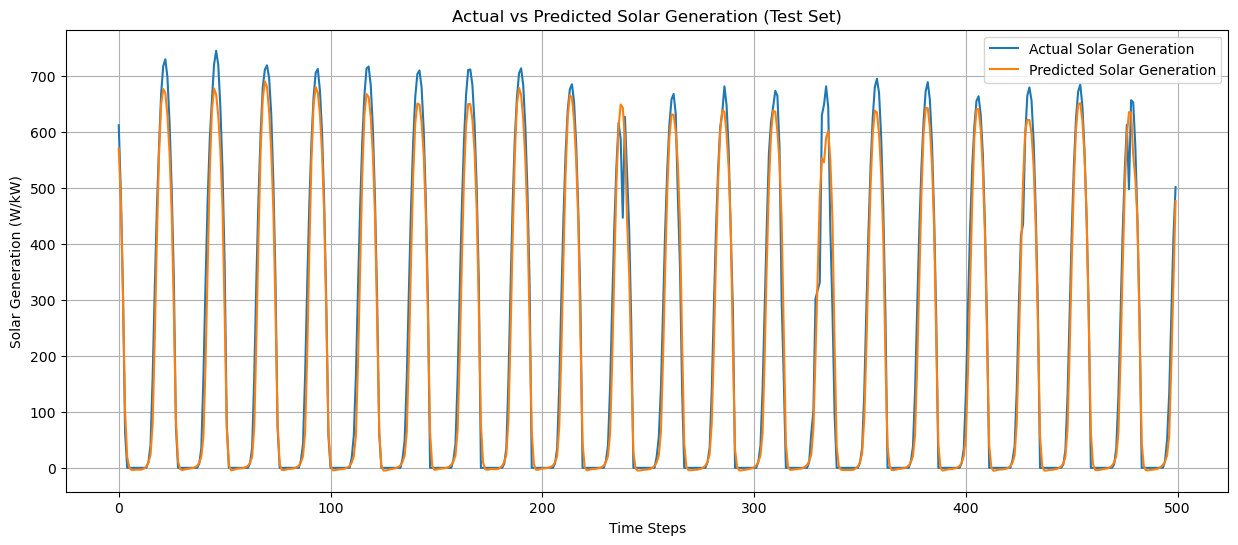

In [22]:
# Plot Results
plt.figure(figsize=(15,6))
plt.plot(y_true[:500], label='Actual Solar Generation')
plt.plot(y_pred[:500], label='Predicted Solar Generation')
plt.title('Actual vs Predicted Solar Generation (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Solar Generation (W/kW)')
plt.legend()
plt.grid(True)
plt.show()

## 8. Conclusion

- Successfully developed an **LSTM-based model** for forecasting solar generation using the CityLearn 2022 dataset.
- The model demonstrated strong predictive performance on the test set:
  - **MAE:** 28.56 W/kW
  - **RMSE:** 48.86 W/kW
  - **R² Score:** 0.9652

- The LSTM model effectively captured temporal dependencies and seasonal patterns in solar output, making it suitable for real-world energy forecasting appli optimization

---

**Prepared by:** Shaheer Khan (22JZELE0457)